<a href="https://colab.research.google.com/github/Ashok-nimmala/EXAPLAINABLE-AI/blob/main/researchF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import zipfile
from PIL import Image
import os
from datetime import datetime

zip_path = '/content/drive/MyDrive/pnemonia.zip'  # update path if needed

records = []

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    file_list = zip_ref.namelist()

    # Filter for image files
    img_files = [f for f in file_list if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for i, img_filename in enumerate(img_files):
        # --- Assign label based on folder name inside zip ---
        if "normal" in img_filename.lower():
            label = 0
        elif "pneumonia" in img_filename.lower():
            label = 1
        else:
            continue  # skip unknown folders

        # --- Assign patient_id ---
        # Example: "person123_bacteria_1.jpeg" → patient123
        base = os.path.basename(img_filename)
        patient_id = base.split("_")[0]

        # --- Assign timestamp ---
        # If no date in filename, use index as pseudo-time
        try:
            ts = datetime.strptime(base.split('.')[0], "%Y%m%d")
        except:
            ts = datetime.fromtimestamp(i)

        records.append({
            "patient_id": patient_id,
            "image_path": img_filename,  # store inside-zip path
            "timestamp": ts,
            "label": label
        })

print(f"Built {len(records)} records from {zip_path}")




Built 23074 records from /content/drive/MyDrive/pnemonia.zip


In [5]:
from collections import defaultdict

def group_by_patient(records):
    """
    Groups records by patient_id and sorts each patient's records by timestamp.
    """
    patients = defaultdict(list)
    for rec in records:
        patients[rec["patient_id"]].append(rec)

    # Sort each patient's records by timestamp
    for pid in patients:
        patients[pid] = sorted(patients[pid], key=lambda x: x["timestamp"])

    return patients


In [6]:
patients = group_by_patient(records)
print(f"Patients found: {len(patients)}")


Patients found: 11537


In [11]:
!pip install torch-geometric

In [21]:
# Utilities: create temporal graphs and convert to PyG Data objects.
import os, numpy as np, torch
from PIL import Image
from skimage.transform import resize
import networkx as nx
from torch_geometric.data import Data, InMemoryDataset
import zipfile

def load_image(zip_path, image_path_in_zip, target_size=(224,224)):
    # Extract the image from the zip file to a temporary location
    temp_img_path = "/tmp/" + os.path.basename(image_path_in_zip)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extract(image_path_in_zip, "/tmp/") # Extract to a temporary directory

    img = Image.open(temp_img_path).convert('L')  # grayscale X-ray
    arr = np.array(img)
    arr = resize(arr, target_size, preserve_range=True).astype(np.float32) / 255.0
    # Expand channel dimension
    os.remove(temp_img_path) # Clean up the temporary file
    return arr[np.newaxis, ...]

def group_by_patient(records):
    # records : list of dicts with keys: {'patient_id','image_path','timestamp', 'label'}
    patients = {}
    for r in records:
        patients.setdefault(r['patient_id'], []).append(r)
    # sort by timestamp
    for pid in patients:
        patients[pid].sort(key=lambda x: x['timestamp'])
    return patients

def build_temporal_graph_for_patient(zip_path, patient_records, feature_extractor=None):
    # patient_records: list of record dicts for one patient (sorted by time)
    # feature_extractor: callable(image_array)->feature_vector. If None, flatten small image.
    node_feats = []
    labels = []
    edge_index = [[], []]
    for i, rec in enumerate(patient_records):
        img = load_image(zip_path, rec['image_path'])
        if feature_extractor is None:
            feat = img.reshape(-1)[:4096]  # simple flatten (trim/pad to 4096)
            if feat.size < 4096:
                feat = np.pad(feat, (0, 4096-feat.size))
            feat = feat.astype(np.float32)
        else:
            feat = feature_extractor(img)
        node_feats.append(feat)
        labels.append(rec.get('label', 0))
        # connect consecutive timepoints (bidirectional)
        if i>0:
            edge_index[0].extend([i-1, i])
            edge_index[1].extend([i, i-1])
    if len(node_feats)==0:
        return None
    x = torch.tensor(np.vstack(node_feats), dtype=torch.float)
    edge_index = torch.tensor(edge_index, dtype=torch.long)
    y = torch.tensor(labels, dtype=torch.long)
    data = Data(x=x, edge_index=edge_index, y=y)
    # store metadata
    data.patient_id = patient_records[0]['patient_id']
    data.timestamps = [r['timestamp'] for r in patient_records]
    data.image_paths = [r['image_path'] for r in patient_records]
    return data

class TemporalXrayDataset(InMemoryDataset):
    def __init__(self, zip_path, patient_groups, transform=None, pre_transform=None, feature_extractor=None):
        super().__init__(None, transform, pre_transform)
        self.data_list = []
        for pid, recs in patient_groups.items():
            d = build_temporal_graph_for_patient(zip_path, recs, feature_extractor=feature_extractor)
            if d is not None:
                self.data_list.append(d)
        self.data, self.slices = self.collate(self.data_list)

    def get(self, idx):
        return self.data_list[idx]

# Example usage (you must adapt records to your notebook's variables):
# records = [{'patient_id':'p1','image_path':'/content/img1.png','timestamp':'2020-01-01','label':1}, ...]
# patients = group_by_patient(records)
# dataset = TemporalXrayDataset(patients)

In [22]:

import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.explain import GNNExplainer

class TemporalGAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels=64, out_channels=2, heads=4, dropout=0.2):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, concat=True)
        self.conv2 = GATConv(hidden_channels*heads, hidden_channels, heads=1, concat=True)
        self.lin = torch.nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index, batch=None):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        # If batched temporal graphs are used, pool per graph
        if batch is not None:
            x = global_mean_pool(x, batch)
        else:
            # If single graph per forward, average node embeddings
            x = x.mean(dim=0, keepdim=True)
        out = self.lin(x)
        return out

# Explainability example:
def explain_graph(model, data, index_to_explain=0, epochs=200):
    explainer = GNNExplainer(model, epochs=epochs)
    node_feat_mask, edge_mask = explainer.explain_graph(data.x, data.edge_index)
    return node_feat_mask, edge_mask


In [14]:

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from torch_geometric.loader import DataLoader

def train(model, loader, optimizer, device='cpu'):
    model.train()
    losses = []
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, batch=torch.zeros(data.x.size(0), dtype=torch.long).to(device))
        # assume y is per-graph: take first element
        y = data.y[0].to(device).unsqueeze(0)
        loss = F.cross_entropy(out, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses)) if losses else 0.0

def evaluate(model, loader, device='cpu'):
    model.eval()
    ys = []
    preds = []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, batch=torch.zeros(data.x.size(0), dtype=torch.long).to(device))
            prob = F.softmax(out, dim=1).cpu().numpy()
            pred = prob.argmax(axis=1)[0]
            preds.append(pred)
            ys.append(int(data.y[0].cpu().item()))
    acc = accuracy_score(ys, preds) if ys else 0.0
    f1 = f1_score(ys, preds, zero_division=0) if ys else 0.0
    # AUC requires probability for positive class and at least two classes in ys
    try:
        auc = roc_auc_score(ys, [p[1] for p in prob]) if len(set(ys))>1 else None
    except Exception:
        auc = None
    return {'accuracy':acc, 'f1':f1, 'auc':auc}

# Example training scaffold (adjust hyperparams for real training):
# dataset = TemporalXrayDataset(patients)
# loader = DataLoader(dataset.data_list, batch_size=1, shuffle=True)
# model = TemporalGAT(in_channels=4096, hidden_channels=64, out_channels=2)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
# for epoch in range(10):
#     loss = train(model, loader, optimizer, device='cuda')
#     metrics = evaluate(model, loader, device='cuda')
#     print(epoch, loss, metrics)


In [25]:

import matplotlib.pyplot as plt
import numpy as np

def overlay_heatmap_on_image(image_path, patch_importances, patch_grid=(4,4)):
    # image_path: original xray
    # patch_importances: list or array with length = patch_grid[0]*patch_grid[1]
    img = Image.open(image_path).convert('L')
    img_arr = np.array(img, dtype=float)
    H, W = img_arr.shape
    ph, pw = H//patch_grid[0], W//patch_grid[1]
    heatmap = np.zeros_like(img_arr, dtype=float)
    idx = 0
    for i in range(patch_grid[0]):
        for j in range(patch_grid[1]):
            y0, y1 = i*ph, (i+1)*ph
            x0, x1 = j*pw, (j+1)*pw
            heatmap[y0:y1, x0:x1] = patch_importances[idx]
            idx += 1
    # Normalize heatmap
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    plt.figure(figsize=(6,6))
    plt.imshow(img_arr, cmap='gray')
    plt.imshow(heatmap, alpha=0.5)
    plt.title('Explanation overlay (patch importances)')
    plt.axis('off')
    plt.show()


In [26]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/pnemonia.zip'
extract_path = '/content/xray_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Walk through and list files
for root, dirs, files in os.walk(extract_path):
    for f in files[:5]:  # just first 5
        print(os.path.join(root, f))


/content/xray_data/COVID-19_Radiography_Dataset/README.md.txt
/content/xray_data/COVID-19_Radiography_Dataset/COVID.metadata.xlsx
/content/xray_data/COVID-19_Radiography_Dataset/Normal.metadata.xlsx
/content/xray_data/COVID-19_Radiography_Dataset/Lung_Opacity.metadata.xlsx
/content/xray_data/COVID-19_Radiography_Dataset/Viral Pneumonia.metadata.xlsx
/content/xray_data/COVID-19_Radiography_Dataset/COVID/images/COVID-220.png
/content/xray_data/COVID-19_Radiography_Dataset/COVID/images/COVID-3416.png
/content/xray_data/COVID-19_Radiography_Dataset/COVID/images/COVID-744.png
/content/xray_data/COVID-19_Radiography_Dataset/COVID/images/COVID-1035.png
/content/xray_data/COVID-19_Radiography_Dataset/COVID/images/COVID-917.png
/content/xray_data/COVID-19_Radiography_Dataset/COVID/masks/COVID-220.png
/content/xray_data/COVID-19_Radiography_Dataset/COVID/masks/COVID-3416.png
/content/xray_data/COVID-19_Radiography_Dataset/COVID/masks/COVID-744.png
/content/xray_data/COVID-19_Radiography_Dataset/

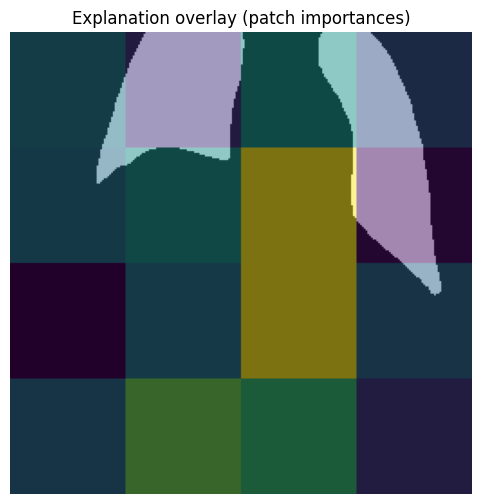

In [28]:
overlay_heatmap_on_image('/content/xray_data/COVID-19_Radiography_Dataset/Viral Pneumonia/masks/Viral Pneumonia-929.png',
                         np.random.rand(16), patch_grid=(4,4))
